# 05a — Florence-2 Auto-BBox: Local Visualization

Quick local test: run Florence-2 `<DENSE_REGION_CAPTION>` on 5 Flickr30k images and visualize results.

| Cell | Purpose |
|------|---------|
| setup | pip install |
| 1 | Imports |
| 2 | Download + patch Florence-2, load model |
| 3 | Stream 5 images from Flickr30k |
| 4 | Run Florence-2 + visualize |

In [5]:
import subprocess, sys
# transformers>=4.44 breaks Florence-2: Florence2LanguageConfig missing forced_bos_token_id.
# Pin to last known-good version. Separate Colab session from graft-training.ipynb so no conflict.
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'transformers==4.42.4', 'datasets', 'huggingface_hub',
    'timm', 'einops', 'tqdm', 'Pillow',
], check=True)
print('Dependencies installed.')

Dependencies installed.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [6]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import os, io, itertools
from pathlib import Path

import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage
from datasets import load_dataset
from transformers import AutoProcessor, AutoModelForCausalLM

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

FLORENCE_MODEL_ID = 'microsoft/Florence-2-base'
N_IMAGES = 5

Device: cpu


In [7]:
# ── 2. Download + patch Florence-2, load model ────────────────────────────────
import re, shutil
from huggingface_hub import snapshot_download

MODEL_LOCAL = Path('florence2_local')

if MODEL_LOCAL.exists():
    shutil.rmtree(MODEL_LOCAL)
print(f'Downloading {FLORENCE_MODEL_ID}...')
snapshot_download(FLORENCE_MODEL_ID, local_dir=str(MODEL_LOCAL))
print('Downloaded.')

# Patch: Florence-2 unconditionally imports flash_attn (both top-level and inside
# if-blocks). dynamic_module_utils.check_imports uses r"^\s*from\s+..." so it
# finds even indented imports. Replace with pass to keep blocks syntactically valid.
mf  = MODEL_LOCAL / 'modeling_florence2.py'
src = mf.read_text()

def _stub(m):
    indent = len(m.group(0)) - len(m.group(0).lstrip())
    return ' ' * indent + 'pass  # flash_attn stubbed'

src = re.sub(r'^\s*(?:from|import) flash_attn\b.*$', _stub, src, flags=re.MULTILINE)
stubs = ('# PATCHED\nflash_attn_func = flash_attn_varlen_func = None\n'
         'index_first_axis = pad_input = unpad_input = None\n\n')
mf.write_text(stubs + src)
print('Patched modeling_florence2.py.')

# Clear transformers modules cache so check_imports sees our patched file.
hf_modules = Path.home() / '.cache' / 'huggingface' / 'modules' / 'transformers_modules'
for stale in [hf_modules / MODEL_LOCAL.name, hf_modules / 'microsoft' / 'Florence-2-base']:
    if stale.exists():
        shutil.rmtree(stale)
        print(f'Cleared stale cache: {stale}')

florence_processor = AutoProcessor.from_pretrained(str(MODEL_LOCAL), trust_remote_code=True)
florence_model = AutoModelForCausalLM.from_pretrained(
    str(MODEL_LOCAL),
    torch_dtype=torch.float16,
    trust_remote_code=True,
    attn_implementation='eager',
).to(DEVICE).eval()

total = sum(p.numel() for p in florence_model.parameters())
print(f'Loaded Florence-2 ({total/1e6:.0f}M params) on {DEVICE}')

Fetching 16 files: 100%|██████████| 16/16 [00:26<00:00,  1.68s/it]


Downloaded.
Patched modeling_florence2.py.
Cleared stale cache: /Users/siddharthraj/.cache/huggingface/modules/transformers_modules/florence2_local
Loaded Florence-2 (231M params) on cpu


In [10]:
# ── 3. Stream 5 images from Flickr30k ────────────────────────────────────────
# Load from the auto-converted parquet revision — avoids the deprecated flickr30k.py script.
ds = load_dataset('nlphuji/flickr30k', streaming=True, split='test',
                  revision='refs/convert/parquet',
                  token=os.environ.get('HF_TOKEN'))

samples = []
for item in ds:
    pil = item['image']
    if not isinstance(pil, PILImage.Image):
        pil = PILImage.open(io.BytesIO(pil['bytes']))
    samples.append({'pil': pil.convert('RGB'), 'caption': item['caption'][0]})
    if len(samples) == N_IMAGES:
        break

print(f'Loaded {len(samples)} images.')
for i, s in enumerate(samples):
    print(f'  [{i}] {s["pil"].size}  "{s["caption"][:60]}..."')

Loaded 5 images.
  [0] (333, 500)  "Two young guys with shaggy hair look at their hands while ha..."
  [1] (500, 374)  "Several men in hard hats are operating a giant pulley system..."
  [2] (375, 500)  "A child in a pink dress is climbing up a set of stairs in an..."
  [3] (500, 333)  "Someone in a blue shirt and hat is standing on stair and lea..."
  [4] (500, 375)  "Two men, one in a gray shirt, one in a black shirt, standing..."


Image (333, 500): 5 regions detected
Image (500, 374): 2 regions detected
Image (375, 500): 7 regions detected
Image (500, 333): 3 regions detected
Image (500, 375): 13 regions detected


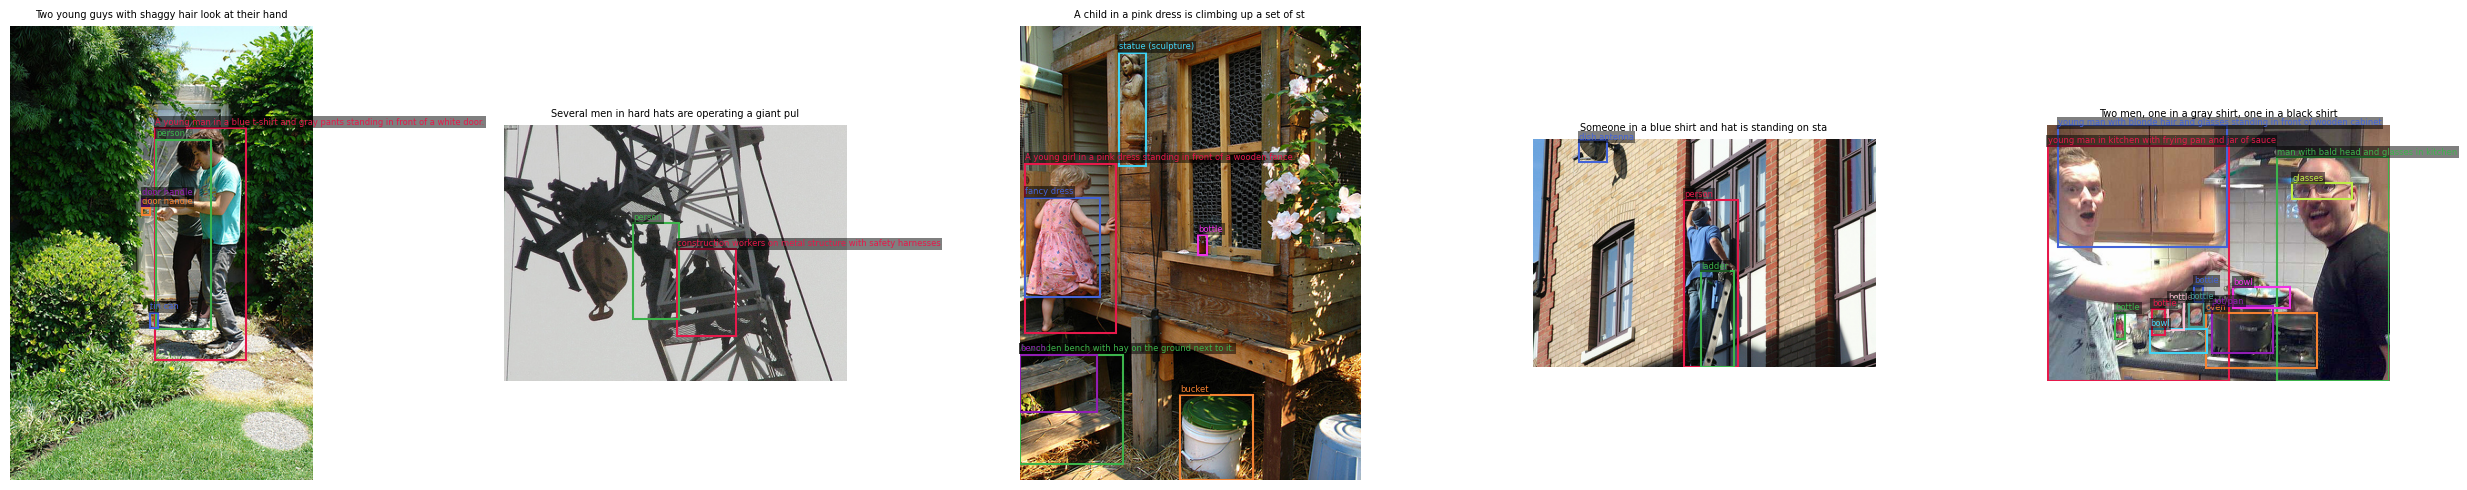

Saved florence2_viz.png


In [11]:
# ── 4. Run Florence-2 + visualize ─────────────────────────────────────────────
def run_florence(pil):
    task   = '<DENSE_REGION_CAPTION>'
    inputs = florence_processor(text=task, images=pil, return_tensors='pt').to(DEVICE, torch.float16)
    with torch.no_grad():
        ids = florence_model.generate(
            input_ids    = inputs['input_ids'],
            pixel_values = inputs['pixel_values'],
            max_new_tokens = 1024,
            num_beams      = 3,
            do_sample      = False,
        )
    text   = florence_processor.batch_decode(ids, skip_special_tokens=False)[0]
    parsed = florence_processor.post_process_generation(
        text, task=task, image_size=(pil.width, pil.height)
    )
    return parsed[task]   # {'bboxes': [[x1,y1,x2,y2],...], 'labels': [...]}


COLORS = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
          '#42d4f4','#f032e6','#bfef45','#fabed4','#469990']

fig, axes = plt.subplots(1, N_IMAGES, figsize=(5 * N_IMAGES, 5))
if N_IMAGES == 1:
    axes = [axes]

for ax, sample in zip(axes, samples):
    pil    = sample['pil']
    result = run_florence(pil)

    ax.imshow(pil)
    ax.set_title(sample['caption'][:50], fontsize=7, wrap=True)
    ax.axis('off')

    for i, (bbox, label) in enumerate(zip(result['bboxes'], result['labels'])):
        x1, y1, x2, y2 = bbox
        color = COLORS[i % len(COLORS)]
        rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=1.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, max(y1-4, 0), label, fontsize=6, color=color,
                bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none'))

    print(f'Image {pil.size}: {len(result["bboxes"])} regions detected')

plt.tight_layout()
plt.savefig('florence2_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved florence2_viz.png')